# BEMKL – Bayesian Efficient Multiple Kernel Learning
## Multiomics BRCA Classification Pipeline

**Reference**: Gönen, M. (2012). *Bayesian Efficient Multiple Kernel Learning*. ICML.  
**Data**: BRCA multiomics (CNV, miRNA, mRNA, Methylation)

The model fuses all four omics modalities via multiple kernels and learns a  
fully Bayesian multilabel (or multiclass one-vs-all) classifier.

## 0 · Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

# Our BEMKL implementation
from bemkl_multilabel import (
    bemkl_train, bemkl_test,
    build_multiomics_kernels,
    default_parameters,
)

## 1 · Load Data

In [2]:
folder = r'./Main_Dataset/Classification_datasets/GS-BRCA/Top'

y_labels = pd.read_csv(f'{folder}/BRCA_label_num.CSV')
X_CNV    = pd.read_csv(f'{folder}/BRCA_CNV_top.CSV',   index_col=0).T
X_miRNA  = pd.read_csv(f'{folder}/BRCA_miRNA_top.CSV', index_col=0).T
X_mRNA   = pd.read_csv(f'{folder}/BRCA_mRNA_top.CSV',  index_col=0).T
X_Methy  = pd.read_csv(f'{folder}/BRCA_Methy_top.CSV', index_col=0).T

print('Shapes:')
for name, df in [('CNV', X_CNV), ('miRNA', X_miRNA),
                 ('mRNA', X_mRNA), ('Methy', X_Methy)]:
    print(f'  {name:6s}: {df.shape}')
print(f'  Labels : {y_labels.shape}')
y_labels.head()

Shapes:
  CNV   : (671, 5000)
  miRNA : (671, 366)
  mRNA  : (671, 5000)
  Methy : (671, 5000)
  Labels : (671, 1)


,Label
0,0
1,1
2,2
3,0
4,0


## 2 · Encode Labels

BEMKL expects a binary ±1 label matrix of shape **(L, N)**.  
For a multiclass problem with *C* classes we use a one-vs-all scheme → L = C.

In [3]:
# ── assume y_labels has one column with integer class indices ──
label_col = y_labels.columns[0]
y_raw = y_labels[label_col].values          # shape (N,)

le = LabelEncoder()
y_int = le.fit_transform(y_raw)             # 0-based integers
C = len(le.classes_)
N = len(y_int)

# One-vs-all: Y[c, n] = +1 if sample n belongs to class c, else -1
Y_all = -np.ones((C, N), dtype=float)
for c in range(C):
    Y_all[c, y_int == c] = 1.0

print(f'Classes: {le.classes_.tolist()}')
print(f'Y_all shape: {Y_all.shape}   (L={C} labels × N={N} samples)')
print(f'Positive counts per class: {(Y_all > 0).sum(axis=1).tolist()}')

Classes: [0, 1, 2, 3, 4]
Y_all shape: (5, 671)   (L=5 labels × N=671 samples)
Positive counts per class: [353, 42, 132, 31, 113]


## 3 · Train / Test Split

In [4]:
TEST_SIZE = 0.30
SEED      = 42

sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
train_idx, test_idx = next(sss.split(np.zeros(N), y_int))

def split_and_scale(X: np.ndarray):
    X_tr = X[train_idx]
    X_te = X[test_idx]
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)
    return X_tr, X_te

omics_train, omics_test = [], []
for name, df in [('CNV', X_CNV), ('miRNA', X_miRNA),
                 ('mRNA', X_mRNA), ('Methy', X_Methy)]:
    Xv = df.values
    Xtr, Xte = split_and_scale(Xv)
    omics_train.append(Xtr)
    omics_test.append(Xte)
    print(f'{name:6s} → train {Xtr.shape}, test {Xte.shape}')

Y_train = Y_all[:, train_idx]     # (L, N_train)
Y_test  = Y_all[:, test_idx]      # (L, N_test)
y_train = y_int[train_idx]
y_test  = y_int[test_idx]

print(f'\nY_train: {Y_train.shape}   Y_test: {Y_test.shape}')

CNV    → train (469, 5000), test (202, 5000)
miRNA  → train (469, 366), test (202, 366)
mRNA   → train (469, 5000), test (202, 5000)
Methy  → train (469, 5000), test (202, 5000)

Y_train: (5, 469)   Y_test: (5, 202)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


## 4 · Build Kernel Matrices

For each omics modality we compute:
- 10 RBF kernels with widths `2^{-3}, …, 2^6`
- 3 polynomial kernels of degrees 1, 2, 3

→ **13 kernels × 4 modalities = 52 kernels** in total.

All kernel matrices are spherically normalised (unit diagonal).

In [ ]:
gammas  = [2**k for k in range(-3, 7)]   # 10 RBF widths
degrees = [1, 2, 3]                      # 3 poly degrees

Km_train, Km_test = build_multiomics_kernels(
    omics_train, omics_test,
    gammas=gammas, degrees=degrees
)

# BEMKL train function expects shape (D, N, P) where
#   D = N_train (kernel rows), N = N_train (kernel cols), P = # kernels
# build_multiomics_kernels returns (N_train, N_train, P) so we're already good.
print(f'Km_train shape: {Km_train.shape}  (N_tr × N_tr × P)')
print(f'Km_test  shape: {Km_test.shape}   (N_te × N_tr × P)')

Km_train shape: (469, 469, 52)  (N_tr × N_tr × P)
Km_test  shape: (469, 202, 52)   (N_te × N_tr × P)


## 5 · Train BEMKL

In [ ]:
params = default_parameters()
params.update(dict(
    iteration    = 200,
    sigma_g      = 0.1,   # <-- bajar de 1.0 a 0.1
    margin       = 1.0,
    alpha_lambda = 1.0,  beta_lambda = 1.0,
    alpha_gamma  = 1.0,  beta_gamma  = 1.0,
    alpha_omega  = 1.0,  beta_omega  = 1.0,
    progress     = 1,
    seed         = 42
))

print("Training BEMKL …")
state = bemkl_train(Km_train, Y_train, params)
print("Done!")

Training BEMKL …
  iter   10 | ELBO = +nan ⚠ NaN/Inf
  iter   20 | ELBO = +nan ⚠ NaN/Inf
  iter   30 | ELBO = +nan ⚠ NaN/Inf
  iter   40 | ELBO = +nan ⚠ NaN/Inf
  iter   50 | ELBO = +nan ⚠ NaN/Inf
  iter   60 | ELBO = +nan ⚠ NaN/Inf
  iter   70 | ELBO = +nan ⚠ NaN/Inf
  iter   80 | ELBO = +nan ⚠ NaN/Inf
  iter   90 | ELBO = +nan ⚠ NaN/Inf
  iter  100 | ELBO = +nan ⚠ NaN/Inf
  iter  110 | ELBO = +nan ⚠ NaN/Inf
  iter  120 | ELBO = +nan ⚠ NaN/Inf
  iter  130 | ELBO = +nan ⚠ NaN/Inf
  iter  140 | ELBO = +nan ⚠ NaN/Inf
  iter  150 | ELBO = +nan ⚠ NaN/Inf
  iter  160 | ELBO = +nan ⚠ NaN/Inf
  iter  170 | ELBO = +nan ⚠ NaN/Inf
  iter  180 | ELBO = +nan ⚠ NaN/Inf


KeyboardInterrupt: 

## 6 · ELBO Convergence

Finite ELBO values: 0 / 200


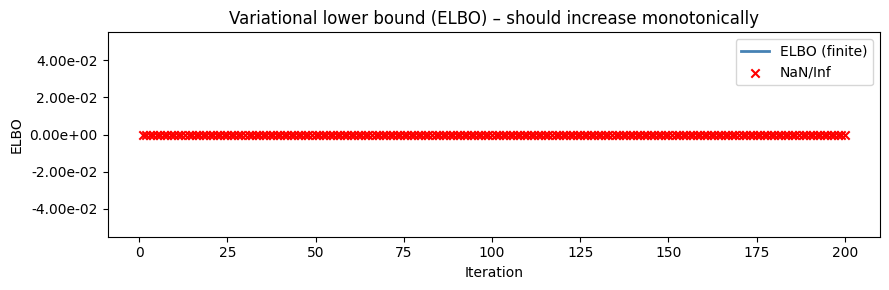

In [8]:
bounds = state.get("bounds")

if bounds is not None:
    iters = np.arange(1, len(bounds) + 1)
    finite = np.isfinite(bounds)

    print(f"Finite ELBO values: {finite.sum()} / {len(bounds)}")
    if finite.sum() > 0:
        print(f"ELBO range: {bounds[finite].min():.4e}  →  {bounds[finite].max():.4e}")

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(iters[finite], bounds[finite], lw=2, color="steelblue", label="ELBO (finite)")
    if (~finite).sum() > 0:
        y_ref = bounds[finite].min() if finite.sum() > 0 else 0.0
        ax.scatter(iters[~finite], np.full((~finite).sum(), y_ref),
                   marker="x", color="red", zorder=5, label="NaN/Inf")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("ELBO")
    ax.set_title("Variational lower bound (ELBO) – should increase monotonically")
    ax.legend()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2e}"))
    plt.tight_layout()
    plt.show()
else:
    print("No ELBO recorded. Set params['progress'] = 1 before training.")

## 7 · Predict & Evaluate

In [9]:
pred = bemkl_test(Km_test, state)
P    = pred['P']            # (L, N_test)  probabilities

# Hard assignment: class with highest probability
y_pred = np.argmax(P, axis=0)

acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {acc * 100:.2f} %')
print()
print(classification_report(y_test, y_pred,
                            target_names=[str(c) for c in le.classes_]))

Test accuracy: 52.48 %

              precision    recall  f1-score   support

           0       0.52      1.00      0.69       106
           1       0.00      0.00      0.00        13
           2       0.00      0.00      0.00        40
           3       0.00      0.00      0.00         9
           4       0.00      0.00      0.00        34

    accuracy                           0.52       202
   macro avg       0.10      0.20      0.14       202
weighted avg       0.28      0.52      0.36       202



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [10]:
# AUC (one-vs-rest)
try:
    auc = roc_auc_score(y_test, P.T, multi_class='ovr')
    print(f'Macro AUC (OvR): {auc:.4f}')
except Exception as e:
    print(f'AUC skipped: {e}')

AUC skipped: Input contains NaN.


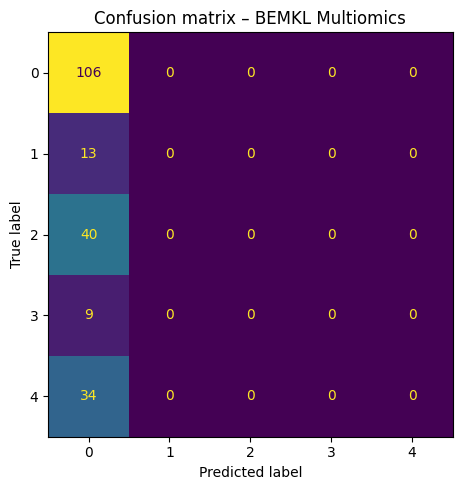

In [11]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion matrix – BEMKL Multiomics')
plt.tight_layout()
plt.show()

## 8 · Kernel Weight Analysis

Inspect which modalities and kernel types the model relied on most.

In [ ]:
e_mu = state['be']['mu'][C:]          # kernel weights (length P)
e_std = np.sqrt(np.diag(state['be']['sigma'])[C:])

modality_names = ['CNV', 'miRNA', 'mRNA', 'Methy']
kernel_labels  = []
n_per_modality = len(gammas) + len(degrees)   # 13

for mod in modality_names:
    kernel_labels += [f'{mod}_rbf_{g:.3f}' for g in gammas]
    kernel_labels += [f'{mod}_poly_{d}'    for d in degrees]

df_weights = pd.DataFrame({
    'kernel'  : kernel_labels,
    'e_mean'  : e_mu,
    'e_std'   : e_std,
    'modality': np.repeat(modality_names, n_per_modality),
})

# Top-20 by absolute weight
top20 = df_weights.reindex(df_weights['e_mean'].abs().nlargest(20).index)

fig, ax = plt.subplots(figsize=(10, 5))
colors = {'CNV': 'steelblue', 'miRNA': 'tomato',
          'mRNA': 'seagreen',  'Methy': 'goldenrod'}
bar_colors = [colors[m] for m in top20['modality']]
ax.barh(top20['kernel'], top20['e_mean'], color=bar_colors, xerr=top20['e_std'], capsize=3)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel('Kernel weight (posterior mean)')
ax.set_title('Top-20 kernel weights by magnitude')
# legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v, label=k) for k, v in colors.items()],
          loc='lower right')
plt.tight_layout()
plt.show()

print('\nPer-modality mean |weight|:')
print(df_weights.groupby('modality')['e_mean'].apply(lambda x: x.abs().mean()).sort_values(ascending=False))

## 9 · Sparse variant (ℓ₁-like sparsity on kernels)

Set very informative priors on `omega` to encourage sparse kernel selection.

In [ ]:
params_sparse = default_parameters()
params_sparse.update(dict(
    iteration   = 200,
    sigma_g     = 0.1,
    margin      = 1.0,
    alpha_omega = 1e-10,   # sparsity-inducing prior
    beta_omega  = 1e+10,
    progress    = 1,
    seed        = 42,
))

print('Training sparse BEMKL …')
state_sparse = bemkl_train(Km_train, Y_train, params_sparse)
print('Done!')

pred_sparse = bemkl_test(Km_test, state_sparse)
y_pred_sparse = np.argmax(pred_sparse['P'], axis=0)
acc_sparse = accuracy_score(y_test, y_pred_sparse)
print(f'Sparse model – Test accuracy: {acc_sparse * 100:.2f} %')

e_sparse = state_sparse['be']['mu'][C:]
selected = np.sum(np.abs(e_sparse) > 0.01)
print(f'Kernels with |weight| > 0.01: {selected} / {len(e_sparse)}')